Loaded Aircraft Models:
                model_name   mass  wing_area     T_0   dc_0      k   lc
0   Cessna-like Light Prop   1200       16.0    4500  0.025  0.080  0.5
1     Learjet Business Jet  10000       28.0   65000  0.020  0.050  0.5
2  Commercial Regional Jet  28000       70.0  140000  0.018  0.045  0.5
3              Fighter Jet  14000       38.0  130000  0.022  0.060  0.5

--- Summary Performance Results ---
                model_name   mass  Best_Climb_Speed_Vy_ms  Max_ROC_ms  \
0   Cessna-like Light Prop   1200                    53.8       11.65   
1     Learjet Business Jet  10000                   181.8       68.25   
2  Commercial Regional Jet  28000                   177.8       51.37   
3              Fighter Jet  14000                   206.8      110.93   

   Max_ROC_ft_min  V_max_ms  
0          2293.0      93.1  
1         13435.0     314.8  
2         10111.0     308.0  
3         21837.0     358.2  


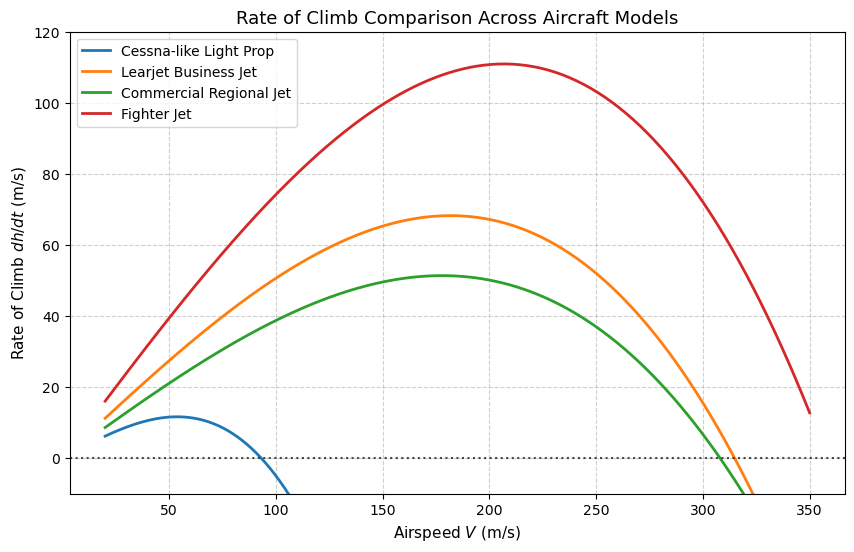

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------------------------------------------
# 1. Global Environmental Constants (Sea Level)
# -------------------------------------------------------------
rho_0 = 1.225   # kg/m^3
g = 9.81        # m/s^2
thro = 0.85     # 85% climb throttle for all models

# -------------------------------------------------------------
# 2. Load the Datasheet with Pandas
# -------------------------------------------------------------
df = pd.read_csv('aircraft_models.csv')

print("Loaded Aircraft Models:")
print(df)

# -------------------------------------------------------------
# 3. Define the Performance Function
# -------------------------------------------------------------
def analyze_aircraft(row):
    """
    Takes one row of aircraft data from the DataFrame
    and computes its performance parameters.
    """
    m = row['mass']
    S = row['wing_area']
    T_max = row['T_0']
    dc_0 = row['dc_0']
    k = row['k']
    lc = row['lc']

    dc = dc_0 + k * (lc ** 2)
    W = m * g
    T = T_max * thro
    v_max = math.sqrt((2 * T) / (rho_0 * S * dc))
    
    # 2. Optimal Climb Airspeed (Vy = V_max / sqrt(3)) from the derived formula for maximum rate of climb.
    v_y = math.sqrt((2 * T) / (3 * rho_0 * S * dc))
    
    # 3. Maximum Rate of Climb (ROC_max)
    drag_at_vy = 0.5 * rho_0 * (v_y ** 2) * S * dc
    roc_max = (T - drag_at_vy) * v_y / W
    
    # 4. Stall speed limit (at lc)
    v_stall = math.sqrt((2 * W) / (rho_0 * S * lc))
    
    return pd.Series({
        'Total_Drag_Coeff': round(dc, 4),
        'V_stall_ms': round(v_stall, 1),
        'Best_Climb_Speed_Vy_ms': round(v_y, 1),
        'Max_ROC_ms': round(roc_max, 2),
        'Max_ROC_ft_min': round(roc_max * 196.85, 0),
        'V_max_ms': round(v_max, 1)
    })

# -------------------------------------------------------------
# 4. Automate Testing Across All Models
# -------------------------------------------------------------
# pandas .apply() runs the function on every row automatically!
results_df = df.apply(analyze_aircraft, axis=1)

# Merge the results back with the original aircraft table
summary = pd.concat([df, results_df], axis=1)

print("\n--- Summary Performance Results ---")
print(summary[['model_name', 'mass', 'Best_Climb_Speed_Vy_ms', 'Max_ROC_ms', 'Max_ROC_ft_min', 'V_max_ms']])

# Optional: Export the results to a new CSV file
summary.to_csv('performance_results_summary.csv', index=False)

# -------------------------------------------------------------
# 5. Automated Multi-Aircraft Comparison Plot
# -------------------------------------------------------------
plt.figure(figsize=(10, 6))
velocities = np.linspace(20, 350, 300)

for _, plane in df.iterrows():
    m = plane['mass']
    S = plane['wing_area']
    T = plane['T_0'] * thro
    dc = plane['dc_0'] + plane['k'] * (plane['lc'] ** 2)
    W = m * g
    
    # Rate of climb curve: ROC(v) = (Thrust - Drag) * v / Weight
    drags = 0.5 * rho_0 * (velocities ** 2) * S * dc
    rocs = (T - drags) * velocities / W
    
    plt.plot(velocities, rocs, linewidth=2, label=plane['model_name'])

plt.axhline(0, color='black', linestyle=':', alpha=0.7)
plt.xlabel('Airspeed $V$ (m/s)', fontsize=11)
plt.ylabel('Rate of Climb $dh/dt$ (m/s)', fontsize=11)
plt.title('Rate of Climb Comparison Across Aircraft Models', fontsize=13)
plt.ylim(-10, 120)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()